In [1]:
cd("/home/jzhang/1TB1/Arhyas_Command")
using Pkg; 
Pkg.activate(".")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Plots")
using CSV
using DataFrames
using Plots

  Activating new project at `/media/jzhang/1TB1/Arhyas_Command`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed SentinelArrays ─ v1.4.9
   Installed Compat ───────── v4.18.1
   Installed Preferences ──── v1.5.2
   Installed CSV ──────────── v0.10.16
  Installing 1 artifacts
   Installed artifact testfiles 6.2 MiB
    Updating `/media/jzhang/1TB1/Arhyas_Command/Project.toml`
  [336ed68f] + CSV v0.10.16
    Updating `/media/jzhang/1TB1/Arhyas_Command/Manifest.toml`
  [336ed68f] + CSV v0.10.16
  [944b1d66] + CodecZlib v0.7.8
  [34da2185] + Compat v4.18.1
  [9a962f9c] + DataAPI v1.16.0
  [e2d170a0] + DataValueInterfaces v1.0.0
  [48062228] + FilePathsBase v0.9.24
  [842dd82b] + InlineStrings v1.4.5
  [82899510] + IteratorInterfaceExtensions v1.0.0
  [bac558e1] + OrderedCollections v1.8.1
  [69de0a69] + Parsers v2.8.3
  [2dfb63ee] + PooledArrays v1.4.3
  [aea7be01] + PrecompileTools v1.3.3
  [21216c6a] + Preferences v1.5.2 [loaded: v

2245


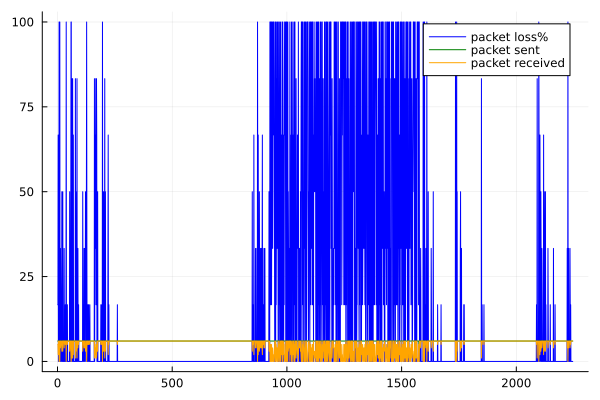

In [43]:
try
    # Read the CSV files into  DataFrame, now transposed, and complete rewrite the reading routine
    PING_DICT = CSV.read("/home/jzhang/1TB1/Arhyas_Command/14.148.89.185.ping_stats_trend.csv", DataFrame, header=false)
   
    t = 1
    Δt = 1
    #@show t
   
    time_sequence = [t]
    packet_sent_sequence = [PING_DICT[1, 1]]
    packet_received_sequence = [PING_DICT[1, 2]]
    packet_lost_rate_sequence = [PING_DICT[1, 3]]

    println(size(PING_DICT,1))
        
    for i in 1:size(PING_DICT, 1)
      t += Δt
      push!(time_sequence, t)
      #print(PING_DICT[i, 1], '|', PING_DICT[i, 2], '|', PING_DICT[i, 3], '\n')
      push!(packet_sent_sequence, PING_DICT[i, 1])
      push!(packet_received_sequence, PING_DICT[i, 2])
      push!(packet_lost_rate_sequence, PING_DICT[i, 3])
    end

    using Plots
    plot(time_sequence, packet_lost_rate_sequence, label="packet loss%", color="blue")
    plot!(time_sequence,packet_sent_sequence, label="packet sent", color="green")
    plot!(time_sequence, packet_received_sequence, label="packet received", color="orange")
    
catch e
    println("Error during CSV processing or data population: ", e)
    # Handle the error appropriately, e.g., exit, rethrow, or log.
    # rethrow(e) # Uncomment to rethrow the error
end
  